# Credit Card Fraud Prediction 

---
embed-resources: true
echo: false
---

## Introduction

Every day, billions of credit card transactions are processed around the world. To detect fraud in real time, professionals have to develop a sophisticated system relying on machine learning models to analyze each transaction. However, it still poses a big challenge: there is a high class imbalance between fraudulent and genuine transactions since fraud is extremely rare in many cases. 

Therefore, we aim to develop an intelligent fraud detection systen that will balance loss prevention by reducing both missed fraud cases and unecessary transaction denials. This system will leverage patterns from historical transation data to autonatically identify whether a transation is likely to be fraudulent in real time. 

The data used in this project includes thousands of credit card transactions that happened in 2 days, transformed through principal component analysis to retain key behavorial information. By training and evaluating various models on these data, we hope to build a fraud detection model that improves operational efficiency, minimizes risk exposure, and strengthens the institution's overall fraud management capabilities. 

## Methods

In [24]:
# basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# model imports
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# metric imports
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import ConfusionMatrixDisplay

# model selection imports
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_friedman1, make_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    fbeta_score,
)

# preprocessing imports
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

The model uses data from the [Kaggle's Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/). This dataset compiles real credit card transactions processed over two days, where fraudulent transations account for under 0.2% of the total volume. To preserve customer privacy, the original features were replaced with 28 principal components through PCA transformation to capture essential patterns. 

### Data

In [16]:
# load data
fraud_train = pd.read_parquet(
    "https://lab.cs307.org/fraud/data/fraud-train.parquet",
)
fraud_test = pd.read_parquet(
    "https://lab.cs307.org/fraud/data/fraud-test.parquet",
)

#### Data Dictionary

**`Fraud`**

- `[int64]` status of the transaction. `1` indicates a fraudulent transaction and `0` indicates not fraud, a genuine transaction.

**`Amount`**

- `[float64]` amount (in dollars) of the transaction.

**`PC01`** - **`PC28`**

- `[float64]` the 28 principal components that encode information such as location and type of purchase while preserving customer privacy.

#### Summary Statistics

Using the data, the key statistics are as follow: 

* Number of samples: 54276
* Number of features: 29

**Fraud (Target) Balance**

In [6]:
pd.DataFrame({'count': (fraud_train['Fraud']).value_counts(), 'proportions':((fraud_train['Fraud']).value_counts()/len(fraud_train))})

,count,proportions
Fraud,,
0,53961,0.994196
1,315,0.005804


**Amount | Fraud Status**

In [ ]:
pd.DataFrame(fraud_train.groupby('Fraud')['Amount'].agg(['mean','std','median','max']))

,mean,std,median,max
Fraud,,,,
0,88.065104,241.451144,21.80,10199.44
1,110.947016,254.978960,6.99,2125.87


#### Exploratory Visualization

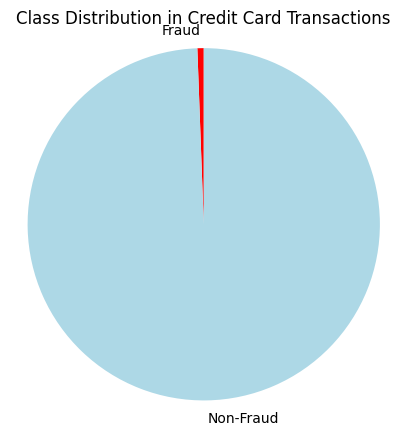

In [ ]:
# exploratory visualization
numfraud = 315
nonfraud = len(fraud_train) - numfraud
sizes = [numfraud, nonfraud]
labels = ["Fraud", "Non-Fraud"]
colors = ["red", "lightblue"]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, colors=colors, startangle=90)
plt.title("Class Distribution in Credit Card Transactions")
plt.axis("equal")
plt.show()

::: {.caption}

**Figure 1.** A pie chart showing the amount of fraudulent vs. genuine transations. This shows the imbalnce between the two classes, highlighting the rarity of credit card fraud cases.

:::

### Models

A classification pipeline was constructed to predict the likelihood of fraudulent credit card transactions based on their features. The process comprised several main steps:

* **Preprocssing:** All numerical features were examined for missing values Missing values in numerical features were imputed using mean values and standardized to ensure uniform scale. The dataset did not include categorical variables requiring imputation or encoding, and unnecessary features were excluded upfront to avoid misleading information. 

* **Model Selection:** Various machine learning models were compared for their ability to handle imbalanced classification. A decision Tree Classifier was ultimately selected as it provided transparent logic, good performance on tabular data, and did not require extensive parameter tuning. 

* **Tuning:** Hyperparameters such as tree depth, random state, and class weights list were optimized using grid search combined with cross-validation. Model selection prioritized maximizing recall and balanced accuracy. 

* **Pipeline:** All preprocessing steps and the estimator were integrated into a single `sklearn` pipline, ensuring consistency and reproducibility throughout model training and deployment. 

* **Evaluation:** The final model was trained on the provided training set and evaluated on the test set. Performance was assessed using precision score and recall score, which allows for a nuanced assessment of the model's ability to detect fraud while minimizing false alarms.

The data was partitioned into training sets and test sets. The test sets served as an unseen sample to evaluate the model's ability to predict fraudulent transactions.

In [17]:
# create X and y for train
X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]

# create X and y for test
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

To evaluate the effectiveness of the developed model, fraud predictions were generated on the test datasets and measured using classification metrics such as precision and recall score. High values on these metrics indicate the model's ability to accurately identify fraudulent transactions in real-world scenarios, supporting its potential for automating fraud detection. 

In [19]:
#train a model 
num_features = ['Amount', 'PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC06', 'PC07', 'PC08', 'PC09', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28']

#preprocessing for num features 
numeric_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

#create general preprocessor 
preprocessor = ColumnTransformer(
    [
        ('numeric', numeric_transformer, num_features)
    ],
    remainder= 'drop',
)

#put everything tgt, build knn model 
tree = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier()),
    ]
)
weights_list = [
    {0: 1, 1: 1},
    {0: 1, 1: 2},
    "balanced",
]

rf_param_grid = {
    "classifier__random_state": [5,20],
    "classifier__max_depth": [2, 20],
    "classifier__class_weight" : weights_list,
}

scoring = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(fbeta_score, beta=2),
}

rf_grid = GridSearchCV(
    tree,
    rf_param_grid,
    cv=5,
    scoring=scoring,
    refit='f1'
)

rf_grid.fit(X_train, y_train)

y_test_pred = rf_grid.predict(X_test)

# calculate and print the test accuracy
test_prec = precision_score(y_test, y_test_pred)


test_rec = recall_score(y_test, y_test_pred)



## Results

The model achieved a precision score of **0.93** and a recall score of **0.82** on the test data, indicating that its predicted classifications are largely accurate. This performance demonstrates the potential of the model to provide accurate and reliable classification of fraudulent vs. genuine credit card transactions.

In [20]:
# report model metrics
print(f"Test precision score: {test_prec}")
print(f"Test recall score: {test_rec}")

Test precision score: 0.9285714285714286
Test recall score: 0.8227848101265823


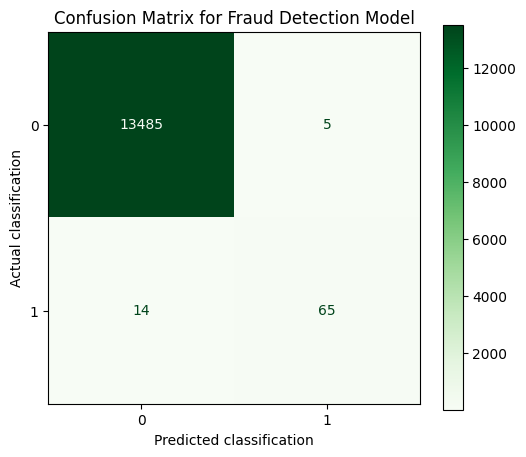

In [36]:
# summary figure
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=ax,
    display_labels= sorted(set(y_test)),
    im_kw={"cmap": "Greens"}
)

ax.set_title('Confusion Matrix for Fraud Detection Model')
ax.set_xlabel("Predicted classification")
ax.set_ylabel("Actual classification")
ax.grid(False)
plt.show()

::: {.caption}

**Figure 2.** The confusion matric for the fraud detection model on the test set, showing the number of correct and incorrect predictions for both fraudualent and genuine transaction classes. The model still has difficulty correctly identifying some fraudulent transactions, meaning there are still some False Negatives classified by the model.  

:::

## Discussion

#### Conclusion 

Based on the model's current performance and the scenario of automated fraud detection for credit card transactions, I believe that this model holds strong promises to the approach. However, I would not deploy the present model in production just yet without further refinement and extensive validation. While the decision tree classifier demonstrates that predicting transaction fraud from data features is feasible, additional safeguards are required before the model can be reliably used in the current management process. 

#### Justification 

Although the model achieved a precision score of 0.93 and a recall score of 0.82 on the test data, it is still not enough for deployment. In real-world contexts, the consequences of both false negatives (missed fraud) and false positices (legitimate transactions flagged) extend to many stakeholders. They can directly impact monetary loss, customer trust, and operational costs. The confusion matrix shows that despite overall good discrimination, the model still occasionally misclassified fraudulent transactions as genuine, which could result in frustrated customers and lost sales. 

#### Risks 

Deploying the current model may lead to: 

* Genuine transactions being declined, causing inconvenience and damaging customer relationships. 
* Fraudulent transactions being undetected, increasing financial losses and undermining risk controls. 
* Reduced stakeholder trust in automated systems if customers consistently observe errors or inconsistent results.
* Potential bias from the limited historical dataset. which may not capture new fraud schemes.

#### Improvements 

Prior ro full-scale deployment, additional changes can be: 

* Collection of additional, diverse transaction data spanning recent fraud patterns to minimize bias and improve robustness. 
* Include additional hyperparameters for tuning in the model to improve performance. 
* Implement an uncertainty function, where flagged transations are prioritized for review. 
* Establish periodic retraining and ongoing monitoring processes to ensure the model adapts to changing fraud tactics and customer behaviors. 

In summary, deploying this model for fraud detection should proceed with ongoing evaluation, refinement, and safeguards to minimize operational risk.

